## Data Import & preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

In [2]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error

In [3]:
import pickle

In [4]:
# Try using fastparquet if you have it installed
# df = pd.read_parquet('./data/green_tripdata_2021-01.parquet', engine='fastparquet')
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename, engine="fastparquet")

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [5]:
df_train = read_dataframe('./data/green_tripdata_2021-01.parquet')
df_val = read_dataframe('./data/green_tripdata_2021-02.parquet')

In [6]:
len(df_train), len(df_val)

(73908, 61921)

In [7]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [8]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [9]:

target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

## MLflow logging

In [19]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc-taxi-experiment")

<Experiment: artifact_location='/Users/amruthakaruturi/gitrepos/MLOps/mlruns/1', creation_time=1778078532580, experiment_id='1', last_update_time=1778078532580, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}, trace_location=None, workspace='default'>

In [11]:
with mlflow.start_run():
    mlflow.set_tag("developer","ak")
    mlflow.set_tag("model","linear regression")
    mlflow.log_param("train-data-path","./data/green_tripdata_2021-01.parquet")
    mlflow.log_param("valid-data-path","./data/green_tripdata_2021-02.parquet")

    lr = LinearRegression()
    lr.fit(X_train, y_train)
    
    y_pred = lr.predict(X_val)
    
    rmse  = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse",rmse)

In [21]:
with mlflow.start_run():
    mlflow.set_tag("developer", "ak")
    mlflow.set_tag("model", "linear regression")
    mlflow.log_param("train-data-path", "./data/green_tripdata_2021-01.parquet")
    mlflow.log_param("valid-data-path", "./data/green_tripdata_2021-02.parquet")

    lr = LinearRegression()
    lr.fit(X_train, y_train)
    
    y_pred = lr.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

    # --- MOVE THESE INSIDE THE BLOCK ---
    # 1. Save the DictVectorizer (dv) and model (lr) together
    with open("models/lin_reg.bin", "wb") as f_out:
        pickle.dump((dv, lr), f_out)    
    
    # 2. Log the file to the current active run
    mlflow.log_artifact(local_path="models/lin_reg.bin", artifact_path="models_pickle")

In [86]:
with open("models/lin_reg.bin","wb") as f_out:
    pickle.dump((dv,lr),f_out)

In [15]:
with mlflow.start_run():
    mlflow.set_tag("developer","ak")
    mlflow.set_tag("model", "lasso regression")
    mlflow.log_param("train-data-path","./data/green_tripdata_2021-01.parquet")
    mlflow.log_param("valid-data-path","./data/green_tripdata_2021-02.parquet")
    
    alpha = 0.01
    mlflow.log_param("alpha",alpha)
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse",rmse)

Hyperopt is a powerful Python library used for Bayesian Optimization. Unlike a simple Grid Search (which tries every combination) or Random Search (which picks at random), Hyperopt uses logic to "narrow in" on the best hyperparameters by learning from previous results.

Component | Purpose
1. fmin,"The ""runner"" function. It minimizes your loss function over the hyperparameter space."
2. tpe,Tree-structured Parzen Estimator. This is the algorithm that decides which set of hyperparameters to try next based on past performance.
3. hp,"The ""Space"" builder. Contains functions like hp.uniform or hp.choice to define the range of your parameters."
4. STATUS_OK,"A mandatory signal sent back to Hyperopt to confirm a specific ""trial"" finished successfully."
5. Trials,"An object that stores the entire history (database) of every configuration tried, including the resulting loss."
6. scope,"Used to wrap functions (like scope.int) to ensure Hyperopt passes the correct data type (e.g., forcing a float to be an integer)."

In [16]:
!pip install --upgrade setuptools

In [11]:
import sys
from types import ModuleType

# --- STEP 1: PYTHON 3.14 COMPATIBILITY HACK ---
# This tricks hyperopt into thinking pkg_resources exists
pkg_mock = ModuleType("pkg_resources")
pkg_mock.get_distribution = lambda name: None
pkg_mock.resource_filename = lambda name, path: ""
sys.modules["pkg_resources"] = pkg_mock

# NOW do your imports
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [12]:
# import xgboost as xgb

# from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
# from hyperopt.pyll import scope

In [14]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val,label=y_val)

In [33]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain = train,
            num_boost_round = 100, # caps the max no.of trees can be formed to predict previous trees residuals.
            evals = [(valid, "validation")],
            early_stopping_rounds = 5 # controls generation of the next trees
        )
        y_pred = booster.predict(valid)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse",rmse)
    return {"loss":rmse, "status":STATUS_OK}

**What reg:linear specifically means:**
1. reg: Stands for Regression. It tells XGBoost that you are trying to predict a continuous numerical value (like a price, temperature, or age) rather than a category (like "spam" or "not spam").
2. linear: This refers to Linear Regression. It means the model will use the standard squared error loss to evaluate its predictions.

**ObjectiveString -> Task Type,Output Type**
1. reg:squarederror -> Regression,"Continuous numbers (e.g., 50,000)"
2. binary:logistic -> Binary Classification,Probability between 0 and 1
3. multi:softmax -> Multi-class Classification,"The actual class label (e.g., 0,1,2)"

In [34]:
search_space = {
    "max_depth": scope.int(hp.quniform("max_depth", 4,100, 1)),
    "learning_rate": hp.loguniform("learning_rate", -3, 0),
    "reg_alpha": hp.loguniform("reg_alpha", -5,-1),
    "reg_lambda": hp.loguniform("reg_lambda",-6,-1),
    "min_child_weight": hp.loguniform("min_child_weight", -1, 3),
    "objective": "reg:linear",
    "seed": 42
}

best_result = fmin(
    fn=objective,
    space = search_space,
    algo = tpe.suggest,
    max_evals= 50, # max no.of set of parameters to try
    trials = Trials(),
    # Stop if no improvement for 10 trials
    # early_stop_fn=early_stop.no_progress_loss(10)
)

  0%|                                                          | 0/50 [00:00<?, ?trial/s, best loss=?]

/Users/amruthakaruturi/gitrepos/MLOps/env/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [16:18:18] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:8.67107                                                                           
[1]	validation-rmse:7.29994                                                                           
[2]	validation-rmse:6.80199                                                                           
[3]	validation-rmse:6.62025                                                                           
[4]	validation-rmse:6.53987                                                                           
[5]	validation-rmse:6.50331                                                                           
[6]	validation-rmse:6.47617                                                                           
[7]	validation-rmse:6.46699                                                                           
[8]	validation-rmse:6.46084                                                                           
[9]	validation-rmse:6.45559                                              

/Users/amruthakaruturi/gitrepos/MLOps/env/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [16:18:26] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[6]	validation-rmse:7.13729                                                                           
[7]	validation-rmse:7.02071                                                                           
[8]	validation-rmse:6.93805                                                                           
[9]	validation-rmse:6.88088                                                                           
[10]	validation-rmse:6.84397                                                                          
[11]	validation-rmse:6.81647                                                                          
[12]	validation-rmse:6.79652                                                                          
[13]	validation-rmse:6.78275                                                                          
[14]	validation-rmse:6.77064                                                                          
[15]	validation-rmse:6.76249                                             

...

[1]	validation-rmse:6.85656                                                                           
[2]	validation-rmse:6.68397                                                                           
[3]	validation-rmse:6.64277                                                                           
[4]	validation-rmse:6.63128                                                                           
[5]	validation-rmse:6.62306                                                                           
[6]	validation-rmse:6.61656                                                                           
[7]	validation-rmse:6.60618                                                                           
[8]	validation-rmse:6.60010                                                                           
[9]	validation-rmse:6.59891                                                                           
[10]	validation-rmse:6.59252                                             

/Users/amruthakaruturi/gitrepos/MLOps/env/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [16:24:28] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:9.71959                                                                           
[1]	validation-rmse:8.28276                                                                           
[2]	validation-rmse:7.48933                                                                           
[3]	validation-rmse:7.06480                                                                           
[4]	validation-rmse:6.83724                                                                           
[5]	validation-rmse:6.71382                                                                           
[6]	validation-rmse:6.64052                                                                           
[7]	validation-rmse:6.59471                                                                           
[8]	validation-rmse:6.56540                                                                           
[9]	validation-rmse:6.55039                                              

/Users/amruthakaruturi/gitrepos/MLOps/env/lib/python3.14/site-packages/xgboost/callback.py:385: UserWarning: [16:24:34] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:10.27961                                                                          
[1]	validation-rmse:8.98135                                                                           
[2]	validation-rmse:8.13959                                                                           
[3]	validation-rmse:7.58610                                                                           
[4]	validation-rmse:7.23701                                                                           
[5]	validation-rmse:7.01395                                                                           
[6]	validation-rmse:6.86836                                                                           
[7]	validation-rmse:6.77303                                                                           
[8]	validation-rmse:6.70882                                                                           
[9]	validation-rmse:6.66614                                              

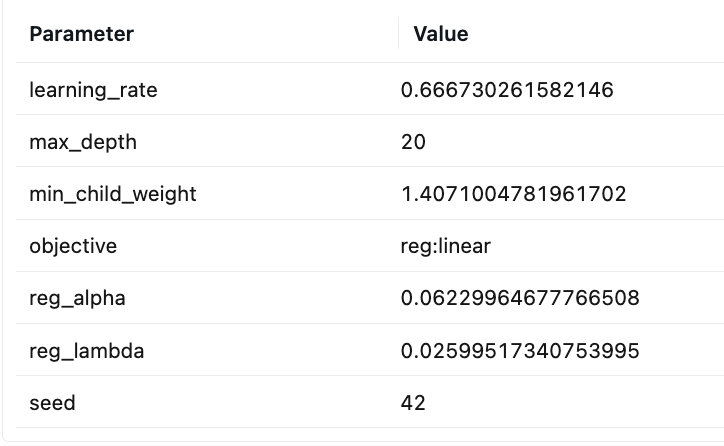

rmse - 6.4034093587947805

In [20]:
params = {
    "max_depth": 20,
    "learning_rate": 0.666730261582146,
    "reg_alpha": 0.06229964677766508,
    "reg_lambda": 0.02599517340753995,
    "min_child_weight": 1.4071004781961702,
    "seed": 42
}

mlflow.xgboost.autolog()
booster = xgb.train(
    params = params,
    dtrain = train,
    num_boost_round = 100,
    evals = [(valid, "validation")],
    early_stopping_rounds = 5
)

2026/05/07 09:02:31 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'd798f028eac74503a0073e05b3f303b0', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow


[0]	validation-rmse:7.69164
[1]	validation-rmse:6.85656
[2]	validation-rmse:6.68397
[3]	validation-rmse:6.64277
[4]	validation-rmse:6.63128
[5]	validation-rmse:6.62306
[6]	validation-rmse:6.61656
[7]	validation-rmse:6.60618
[8]	validation-rmse:6.60010
[9]	validation-rmse:6.59891
[10]	validation-rmse:6.59252
[11]	validation-rmse:6.58741
[12]	validation-rmse:6.58384
[13]	validation-rmse:6.58004
[14]	validation-rmse:6.57691
[15]	validation-rmse:6.57066
[16]	validation-rmse:6.56502
[17]	validation-rmse:6.55772
[18]	validation-rmse:6.55468
[19]	validation-rmse:6.54978
[20]	validation-rmse:6.54608
[21]	validation-rmse:6.54084
[22]	validation-rmse:6.53772
[23]	validation-rmse:6.53244
[24]	validation-rmse:6.52987
[25]	validation-rmse:6.52680
[26]	validation-rmse:6.52565
[27]	validation-rmse:6.52118
[28]	validation-rmse:6.51778
[29]	validation-rmse:6.51449
[30]	validation-rmse:6.51198
[31]	validation-rmse:6.51025
[32]	validation-rmse:6.50360
[33]	validation-rmse:6.50226
[34]	validation-rmse:6.5

2026/05/07 09:02:37 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2026/05/07 09:02:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [17]:
booster.save_config()

'{"learner":{"generic_param":{"device":"cpu","fail_on_invalid_gpu_id":"0","n_jobs":"0","nthread":"0","random_state":"42","seed":"42","seed_per_iteration":"0","validate_parameters":"1"},"gradient_booster":{"gbtree_model_param":{"num_parallel_tree":"1","num_trees":"100"},"gbtree_train_param":{"process_type":"default","tree_method":"auto","updater":"grow_quantile_histmaker","updater_seq":"grow_quantile_histmaker"},"name":"gbtree","specified_updater":false,"tree_train_param":{"alpha":"0.0622996464","colsample_bylevel":"1","colsample_bynode":"1","colsample_bytree":"1","eta":"0.666730285","gamma":"0","grow_policy":"depthwise","interaction_constraints":"","lambda":"0.0259951726","learning_rate":"0.666730285","max_bin":"256","max_cat_threshold":"64","max_cat_to_onehot":"4","max_delta_step":"0","max_depth":"20","max_leaves":"0","min_child_weight":"1.40710044","min_split_loss":"0","monotone_constraints":"()","refresh_leaf":"1","reg_alpha":"0.0622996464","reg_lambda":"0.0259951726","sampling_meth

In [23]:
mlflow.xgboost.autolog(disable=True)

with mlflow.start_run():
    
    best_params = {
        "max_depth": 20,
        "learning_rate": 0.666730261582146,
        "reg_alpha": 0.06229964677766508,
        "reg_lambda": 0.02599517340753995,
        "min_child_weight": 1.4071004781961702,
        "seed": 42
    }

    mlflow.log_params(best_params)
    
    booster = xgb.train(
        params = best_params,
        dtrain = train,
        num_boost_round = 100,
        evals = [(valid, "validation")],
        early_stopping_rounds = 5
    )

    y_pred = booster.predict(valid)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse",rmse)
    with open("models/preprocessor.b", "wb") as f_out:
        pickle.dump(dv, f_out)
    mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")

    mlflow.xgboost.log_model(booster, artifact_path = "models_mlflow")

[0]	validation-rmse:7.69164
[1]	validation-rmse:6.85656
[2]	validation-rmse:6.68397
[3]	validation-rmse:6.64277
[4]	validation-rmse:6.63128
[5]	validation-rmse:6.62306
[6]	validation-rmse:6.61656
[7]	validation-rmse:6.60618
[8]	validation-rmse:6.60010
[9]	validation-rmse:6.59891
[10]	validation-rmse:6.59252
[11]	validation-rmse:6.58741
[12]	validation-rmse:6.58384
[13]	validation-rmse:6.58004
[14]	validation-rmse:6.57691
[15]	validation-rmse:6.57066
[16]	validation-rmse:6.56502
[17]	validation-rmse:6.55772
[18]	validation-rmse:6.55468
[19]	validation-rmse:6.54978
[20]	validation-rmse:6.54608
[21]	validation-rmse:6.54084
[22]	validation-rmse:6.53772
[23]	validation-rmse:6.53244
[24]	validation-rmse:6.52987
[25]	validation-rmse:6.52680
[26]	validation-rmse:6.52565
[27]	validation-rmse:6.52118
[28]	validation-rmse:6.51778
[29]	validation-rmse:6.51449
[30]	validation-rmse:6.51198
[31]	validation-rmse:6.51025
[32]	validation-rmse:6.50360
[33]	validation-rmse:6.50226
[34]	validation-rmse:6.5

2026/05/07 09:42:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [41]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import LinearSVR

mlflow.sklearn.autolog()

for model_class in (RandomForestRegressor, GradientBoostingRegressor, LinearSVR):
    with mlflow.start_run():
        mlflow.log_param("train-data-path","./data/green_tripdata_2021-01.parquet")
        mlflow.log_param("valid-data-path","./data/green_tripdata_2021-02.parquet")
        mlflow.log_artifact("models/preprocessor.b", artifact_path= "preprocessor")
        mlmodel = model_class()
        mlflow.set_tag("model", mlmodel.__class__.__name__)
        mlmodel.fit(X_train, y_train)

        y_pred = mlmodel.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse",rmse)


2026/05/07 14:59:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/07 15:00:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/Users/amruthakaruturi/gitrepos/MLOps/env/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn

In [39]:
LinearSVR().__class__.__name__


'LinearSVR'